In [ ]:
# Step 1: Import libraries and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Please upload your CSV file (WA_Fn-UseC_-Telco-Customer-Churn.csv):")
uploaded = files.upload()

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Quick look at the data
print("\n✅ Dataset loaded successfully!")
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Please upload your CSV file (WA_Fn-UseC_-Telco-Customer-Churn.csv):


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (3).csv

✅ Dataset loaded successfully!
Shape of dataset: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Step 2: Data Cleaning
print("--- Data Cleaning ---")

# Clean TotalCharges (it has blank spaces in the raw CSV)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Drop customerID (not needed for analysis)
df.drop('customerID', axis=1, inplace=True)

# Map SeniorCitizen from 0/1 to No/Yes for better visualization
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Verify cleaning
print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total missing values.")
print("\nData types:")
print(df.dtypes)

--- Data Cleaning ---
Missing values after cleaning:
0 total missing values.

Data types:
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


/tmp/ipykernel_2579/4096502667.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


--- Overall Churn Distribution ---


/tmp/ipykernel_2579/129428376.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


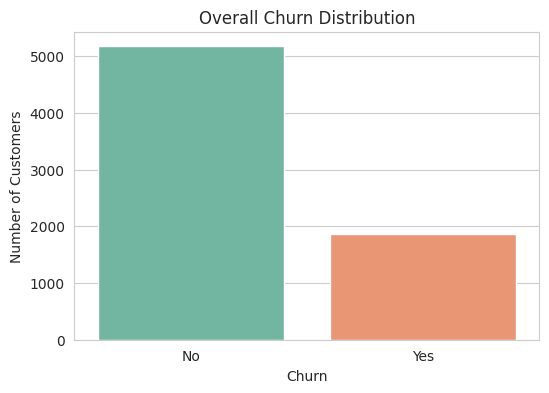

Churn Rate:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64



/tmp/ipykernel_2579/129428376.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Contract', data=df, palette='Set3')


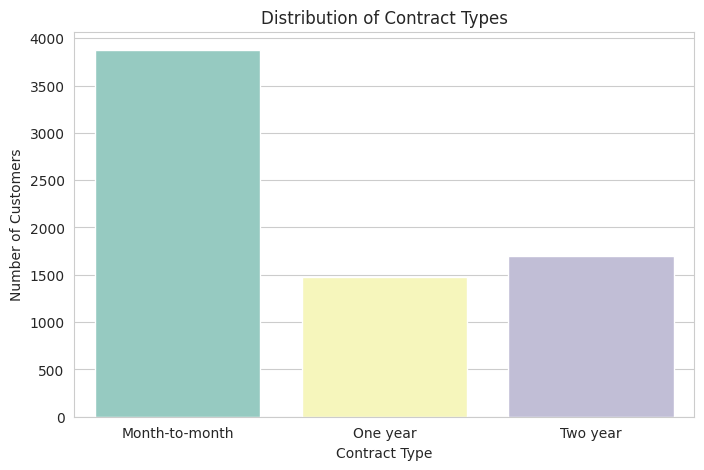

In [ ]:
# Step 3: Univariate Analysis
print("--- Overall Churn Distribution ---")

# Plot 1: Overall Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Overall Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

# Calculate churn rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"Churn Rate:\n{churn_rate}\n")

# Plot 2: Contract Types
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', data=df, palette='Set3')
plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

--- Churn by Key Drivers ---


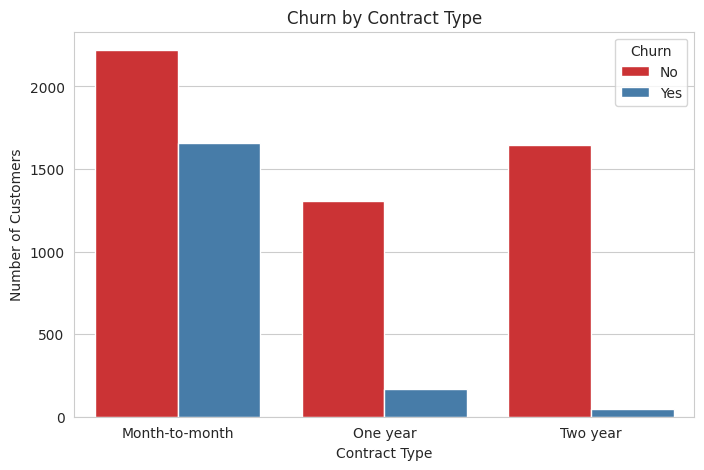

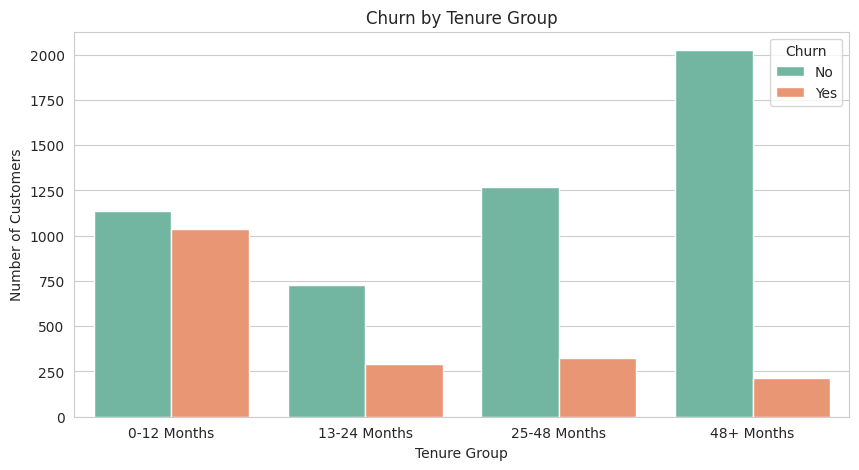

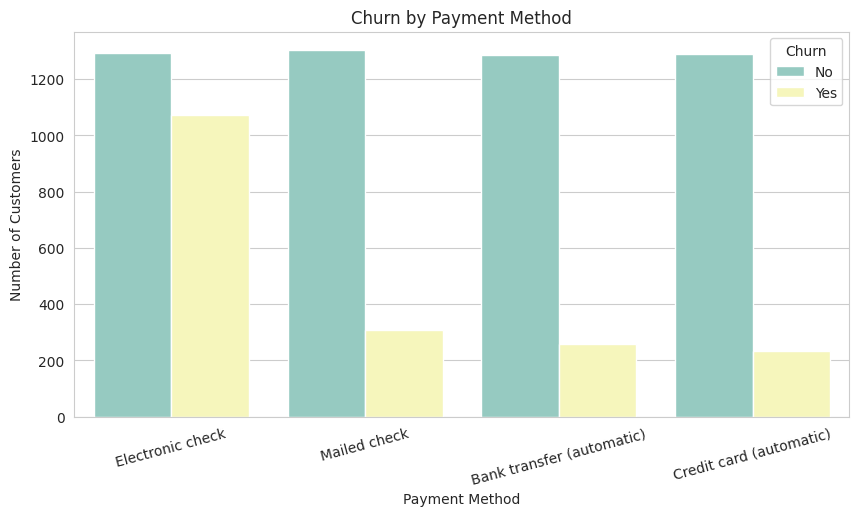

/tmp/ipykernel_2579/1343429568.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set1')


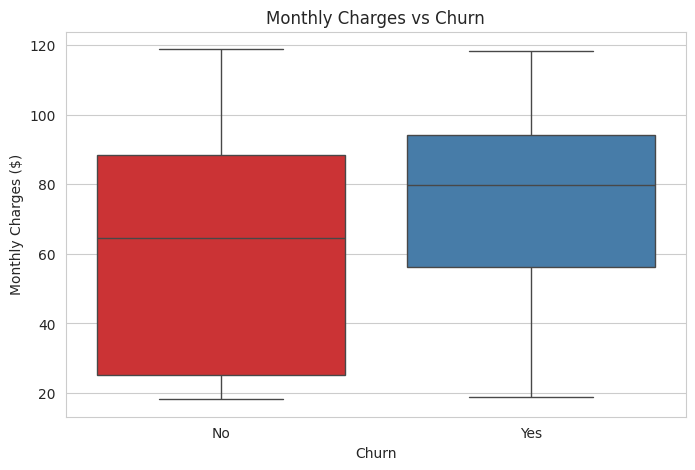

In [ ]:
# Step 4: Bivariate Analysis
print("--- Churn by Key Drivers ---")

# Plot 1: Churn by Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

# Plot 2: Churn by Tenure (using bins)
df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                            labels=['0-12 Months', '13-24 Months', '25-48 Months', '48+ Months'])
plt.figure(figsize=(10, 5))
sns.countplot(x='Tenure_Group', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.show()

# Plot 3: Churn by Payment Method
plt.figure(figsize=(10, 5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set3')
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.show()

# Plot 4: Monthly Charges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set1')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

--- Correlation Heatmap ---


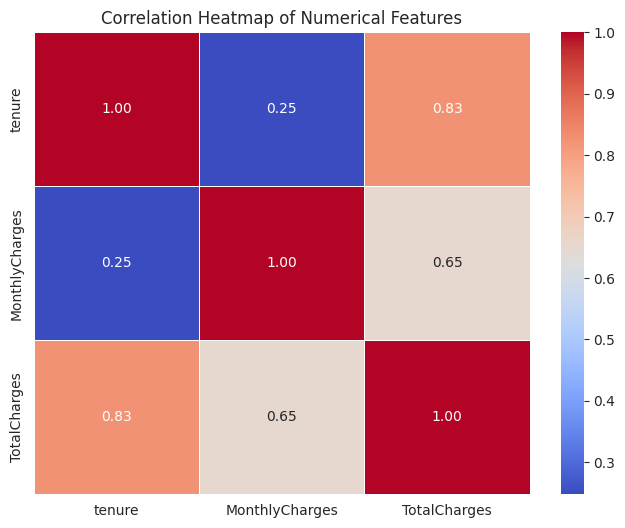


✅ Phase 3 EDA Complete! You have visually proven the key drivers of churn.


In [ ]:
# Step 5: Multivariate Analysis (Correlation)
print("--- Correlation Heatmap ---")

# Select numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df[num_cols].corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

print("\n✅ Phase 3 EDA Complete! You have visually proven the key drivers of churn.")

--- Phase 4: Machine Learning ---
✅ Data prepared: 5634 rows for training, 1409 rows for testing.

--- Training the Model ---
✅ Model training complete!

--- Model Evaluation ---
Accuracy: 79.42%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


--- Top Drivers of Churn ---


/tmp/ipykernel_2579/602203038.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis')


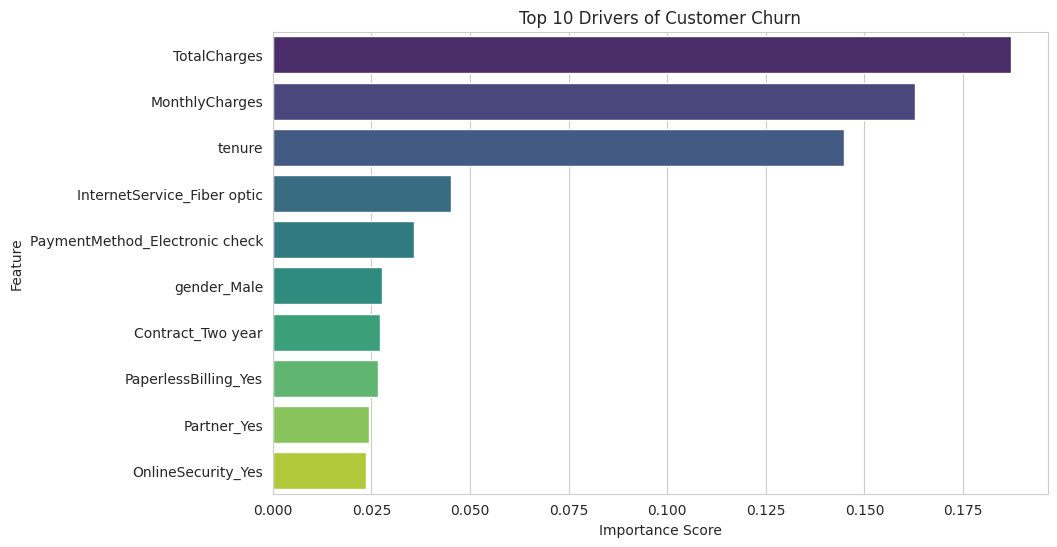


--- Saving Predictions for Power BI ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Predictions saved and downloaded as 'telco_churn_predictions.csv'!


In [ ]:
# ==========================================
# PHASE 4: MACHINE LEARNING (CHURN PREDICTION)
# ==========================================
print("--- Phase 4: Machine Learning ---")

# Step 1: Import ML libraries and prepare data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Churn' from Yes/No to 1/0 (Target Variable)
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn']) # Yes becomes 1, No becomes 0

# Convert all other categorical variables into numbers (One-Hot Encoding)
df_ml = pd.get_dummies(df, drop_first=True)

# Define Features (X) and Target (y)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data prepared: {X_train.shape[0]} rows for training, {X_test.shape[0]} rows for testing.")

# Step 2: Train the Random Forest Model
print("\n--- Training the Model ---")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("✅ Model training complete!")

# Step 3: Evaluate the Model
print("\n--- Model Evaluation ---")
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 4: Find the Top Drivers of Churn (Feature Importance)
print("\n--- Top Drivers of Churn ---")
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis')
plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Step 5: Save Predictions for Power BI (Phase 5 Preparation)
print("\n--- Saving Predictions for Power BI ---")
df['Churn_Probability'] = model.predict_proba(df_ml.drop('Churn', axis=1))[:, 1]

# Save this file so you can use it in Power BI later!
df.to_csv('telco_churn_predictions.csv', index=False)

# Download the file to your laptop
from google.colab import files
files.download('telco_churn_predictions.csv')
print("✅ Predictions saved and downloaded as 'telco_churn_predictions.csv'!")